In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

from config import AGGREGATIONS, BENCHMARKS, RANDOM_SEED
from utils import load_dataset, seasonality_strength, plot_pool_distribution, print_summary, SOURCE_MAP
from scoring.runner import score_source, scores_path
from selection import select_source, save_selection

AGGREGATION = "hourly"
BENCHMARK = "SEASON"
AGG_PARAMS = AGGREGATIONS[AGGREGATION]
BENCH_PARAMS = BENCHMARKS[BENCHMARK]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

print(f"Benchmark: {BENCHMARK}")
print(f"Aggregation: {AGGREGATION}")
print(f"Threshold: {BENCH_PARAMS['metric_col']} {BENCH_PARAMS['metric_op']} {BENCH_PARAMS['threshold']}")
print(f"Sparsity min: {BENCH_PARAMS['sparsity_min']}")
print(f"Sample size: {BENCH_PARAMS['sample_size']} | Seed: {RANDOM_SEED}")

Benchmark: SEASON
Aggregation: hourly
Threshold: max_strength >= 0.7
Sparsity min: 0.4
Sample size: 25 | Seed: 42


## 1 — Scoring

Compute seasonality scores (daily + weekly STL strength) for each source level.
If a score file already exists it is loaded from disk; otherwise `score_source` runs the full computation.

In [2]:
sources = BENCH_PARAMS["levels"]
scores = {}

for source in sources:
    path = scores_path(AGGREGATION, BENCHMARK, source)
    if os.path.exists(path):
        print(f"Loading existing scores: {path}")
        scores[source] = pd.read_csv(path)
    else:
        print(f"Computing scores for {source}...")
        scores[source] = score_source(BENCHMARK, source, aggregation=AGGREGATION)

for source, df in scores.items():
    print(f"\n{source}: {len(df)} series scored")
    display(df.describe().round(3))

Loading existing scores: scores/hourly/SEASON_institutions.csv
Loading existing scores: scores/hourly/SEASON_subnets.csv
Loading existing scores: scores/hourly/SEASON_ips.csv

institutions: 283 series scored


,id_institution,ratio_active,strength_daily,strength_weekly,max_strength
count,283.000,283.000,281.000,281.000,281.000
mean,142.233,0.989,0.619,0.659,0.667
std,82.480,0.073,0.113,0.136,0.129
min,0.000,0.134,0.354,0.258,0.356
25%,71.500,1.000,0.545,0.577,0.589
50%,142.000,1.000,0.634,0.698,0.703
75%,213.500,1.000,0.709,0.764,0.767
max,284.000,1.000,0.833,0.855,0.855



subnets: 548 series scored


,id_institution_subnet,ratio_active,strength_daily,strength_weekly,max_strength
count,548.000,548.000,535.000,535.000,535.000
mean,273.500,0.961,0.551,0.573,0.585
std,158.338,0.143,0.139,0.166,0.159
min,0.000,0.064,0.304,0.225,0.322
25%,136.750,0.999,0.412,0.404,0.417
50%,273.500,1.000,0.570,0.593,0.603
75%,410.250,1.000,0.669,0.723,0.729
max,547.000,1.000,0.890,0.887,0.890



ips: 1000 series scored


,id_ip,ratio_active,strength_daily,strength_weekly,max_strength
count,1000.000,1000.000,183.000,183.000,183.000
mean,860461.454,0.210,0.413,0.424,0.431
std,679140.522,0.308,0.103,0.111,0.111
min,11.000,0.000,0.309,0.323,0.340
25%,266825.500,0.011,0.354,0.364,0.366
50%,635072.500,0.074,0.370,0.382,0.386
75%,1629478.250,0.215,0.426,0.429,0.438
max,2044888.000,1.000,0.828,0.928,0.928


## 2 — Score distributions

Histogram of `max_strength` per level with the selection threshold overlaid.

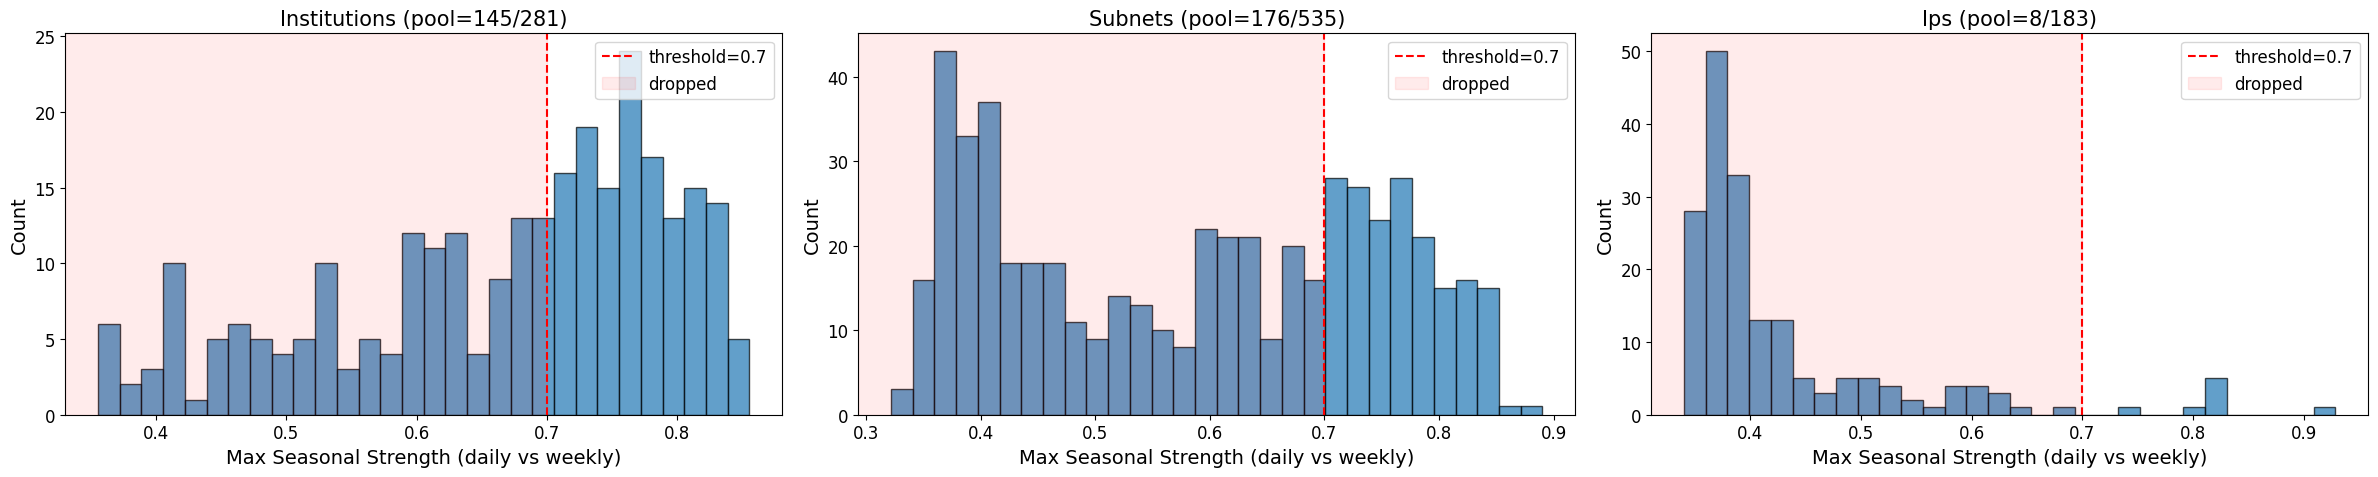

In [3]:
_smin = BENCH_PARAMS["sparsity_min"]
active_scores = {
    s: scores[s][scores[s]["ratio_active"] >= _smin]
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Max Seasonal Strength (daily vs weekly)",
)

## 3 — Selection

Apply sparsity filter, threshold filter, then random sample from the qualifying pool.

In [4]:
selected = {}
pool_sizes = {}

for source in sources:
    ids, pool_size, _ = select_source(BENCHMARK, source, AGGREGATION)
    selected[source] = ids
    pool_sizes[source] = pool_size

print_summary(
    BENCHMARK,
    selected,
    pool_sizes,
    threshold=BENCH_PARAMS["threshold"],
    threshold_name=BENCH_PARAMS["metric_col"],
    sample_size=BENCH_PARAMS["sample_size"],
    seed=RANDOM_SEED,
)

  institutions: 281/283 pass sparsity, pool=145 — selected 25
  subnets: 535/548 pass sparsity, pool=176 — selected 25
  ips: 183/1000 pass sparsity, pool=8 — pool exhausted, taking all 8

SEASON BENCHMARK - Selected Series
Threshold: max_strength >= 0.7
Selection: Random sample of 25 from qualifying pool
Random seed: 42

institutions (25): [15, 16, 38, 39, 52, 56, 63, 70, 96, 112, 123, 132, 147, 158, 183, 194, 195, 204, 208, 217, 231, 235, 249, 252, 261]
  Pool size: 145
subnets (25): [91, 133, 136, 145, 146, 152, 179, 197, 214, 261, 268, 274, 315, 381, 388, 391, 395, 405, 408, 451, 452, 494, 509, 517, 530]
  Pool size: 176
ips (8): [103, 1370, 1845, 10197, 10256, 11188, 11212, 1951628]
  Pool size: 8


### IP sample pool exhausted — fall back to full IP dataset

The IP sample only has 8 qualifying series. Load scores for the full IP dataset (~275k series, scored in chunks via `score_source`) and select from there.

In [5]:
path = scores_path(AGGREGATION, BENCHMARK, "ips_full")
if os.path.exists(path):
    print(f"Loading existing scores: {path}")
    scores["ips"] = pd.read_csv(path)
else:
    print(f"Computing scores for ips_full (chunked)...")
    scores["ips"] = score_source(BENCHMARK, "ips_full", aggregation=AGGREGATION)

print(f"\nips_full: {len(scores['ips'])} series scored")
display(scores["ips"].describe().round(3))

ids, pool_size, _ = select_source(BENCHMARK, "ips_full", AGGREGATION)
selected["ips"] = ids
pool_sizes["ips"] = pool_size

print(f"\nips selected from full dataset ({len(ids)}): {ids}")
print(f"Pool size: {pool_size}")

Loading existing scores: scores/hourly/SEASON_ips_full.csv

ips_full: 275124 series scored


,id_ip,ratio_active,strength_daily,strength_weekly,max_strength
count,275124.000,275124.000,42706.000,42706.000,42706.000
mean,883801.658,0.190,0.403,0.412,0.421
std,666745.924,0.287,0.091,0.096,0.098
min,3.000,0.000,0.192,0.136,0.263
25%,293947.500,0.011,0.354,0.360,0.365
50%,650919.500,0.070,0.369,0.376,0.380
75%,1623585.000,0.192,0.411,0.420,0.430
max,2055783.000,1.000,0.994,0.984,0.994


  ips_full: 42706/275124 pass sparsity, pool=1413 — selected 25

ips selected from full dataset (25): [1370, 1749, 1784, 3313, 6005, 6768, 10280, 13911, 35182, 36419, 38213, 61048, 114939, 119674, 132516, 137574, 139017, 194323, 250872, 305866, 347314, 472452, 518935, 626876, 777653]
Pool size: 1413


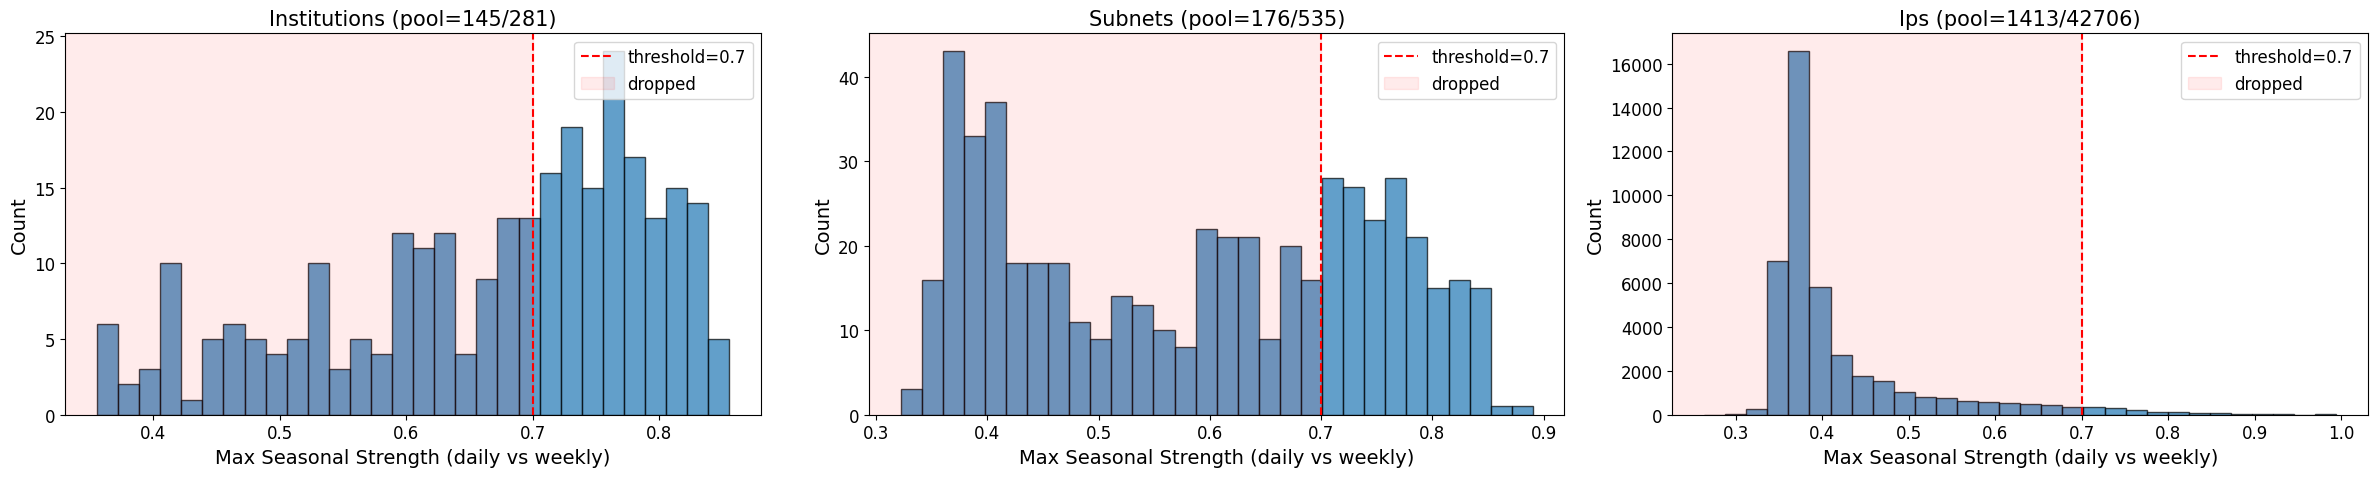

In [6]:
active_scores = {
    s: scores[s][scores[s]["ratio_active"] >= _smin]
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Max Seasonal Strength (daily vs weekly)",
)

## 4 — Detailed scores for selected series

In [7]:
for source in sources:
    _, id_col = SOURCE_MAP[source]
    df_s = scores[source]
    sel = df_s[df_s[id_col].isin(selected[source])].sort_values("max_strength", ascending=False)
    print(f"\n{source.capitalize()} — selected series scores:")
    display(sel)


Institutions — selected series scores:


,id_institution,ratio_active,strength_daily,strength_weekly,max_strength
51,39.0,0.999851,0.574058,0.838692,0.838692
271,63.0,0.999851,0.750340,0.813938,0.813938
21,52.0,0.999851,0.741441,0.813410,0.813410
98,261.0,0.999851,0.748620,0.808547,0.808547
70,70.0,0.999851,0.727034,0.803750,0.803750
252,208.0,0.999851,0.522771,0.785500,0.785500
237,147.0,0.999851,0.693602,0.780934,0.780934
136,56.0,0.999851,0.773447,0.766203,0.773447
106,194.0,0.999851,0.698916,0.767582,0.767582
128,183.0,0.999851,0.669433,0.766271,0.766271



Subnets — selected series scores:


,id_institution_subnet,ratio_active,strength_daily,strength_weekly,max_strength
222,146.0,0.999851,0.691323,0.851889,0.851889
82,91.0,0.999851,0.842245,0.815372,0.842245
72,395.0,0.999851,0.787432,0.833379,0.833379
517,315.0,0.999851,0.713986,0.830990,0.830990
532,268.0,0.999851,0.754927,0.825360,0.825360
132,388.0,0.999851,0.743970,0.816195,0.816195
473,274.0,0.999851,0.724460,0.793948,0.793948
348,136.0,0.999851,0.775939,0.763003,0.775939
421,214.0,0.999851,0.763895,0.722589,0.763895
242,133.0,0.997767,0.678119,0.762905,0.762905



Ips — selected series scores:


,id_ip,ratio_active,strength_daily,strength_weekly,max_strength
113673,518935.0,0.554481,0.992444,0.983030,0.992444
3134,10280.0,0.999851,0.874107,0.866734,0.874107
33618,132516.0,0.776719,0.850592,0.850536,0.850592
79737,347314.0,0.438226,0.831667,0.839730,0.839730
2173,6768.0,0.998809,0.833566,0.806117,0.833566
4266,13911.0,0.568473,0.824581,0.785870,0.824581
1139,3313.0,0.998660,0.724606,0.811083,0.811083
442,1370.0,0.999851,0.545570,0.801723,0.801723
71256,305866.0,0.567728,0.736022,0.800742,0.800742
35068,139017.0,0.651682,0.678808,0.778204,0.778204


## 5 — Verification plots

For a few selected series per level: raw time series, STL decomposition, and ACF.

In [8]:
def plot_stl_verification(df, id_col, ts_id, agg_params):
    grp = df[df[id_col] == ts_id].reset_index(drop=True)
    t = grp["datetime"]
    y_log = np.log1p(grp["n_bytes"].astype(float))

    s_daily = seasonality_strength(y_log, agg_params["daily_period"])
    s_weekly = seasonality_strength(y_log, agg_params["weekly_period"])
    best_period = agg_params["daily_period"] if s_daily >= s_weekly else agg_params["weekly_period"]
    period_label = f'daily ({agg_params["daily_period"]}h)' if best_period == agg_params["daily_period"] else f'weekly ({agg_params["weekly_period"]}h)'
    stl = STL(y_log, period=best_period).fit()

    components = [
        ('Observed — log1p(n_bytes)', y_log.values, '#1f77b4'),
        ('Trend', stl.trend.values, '#2ca02c'),
        (f'Seasonal (period={period_label})', stl.seasonal.values, '#9467bd'),
        ('Residual', stl.resid.values, '#d62728'),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, (title, vals, color) in zip(axes, components):
        ax.plot(t, vals, linewidth=0.5, color=color)
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    axes[0].set_title(
        f'{id_col}={int(ts_id)}  —  seasonal strength: daily={s_daily:.3f}, weekly={s_weekly:.3f}'
    )
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

100%|████████████████████████████| 3/3 [00:07<00:00,  2.49s/it]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [195  38 208], Length=3
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch size: 128
      

institutions (AGG_1_HOUR): 3 series loaded

INSTITUTIONS — verifying 3 series


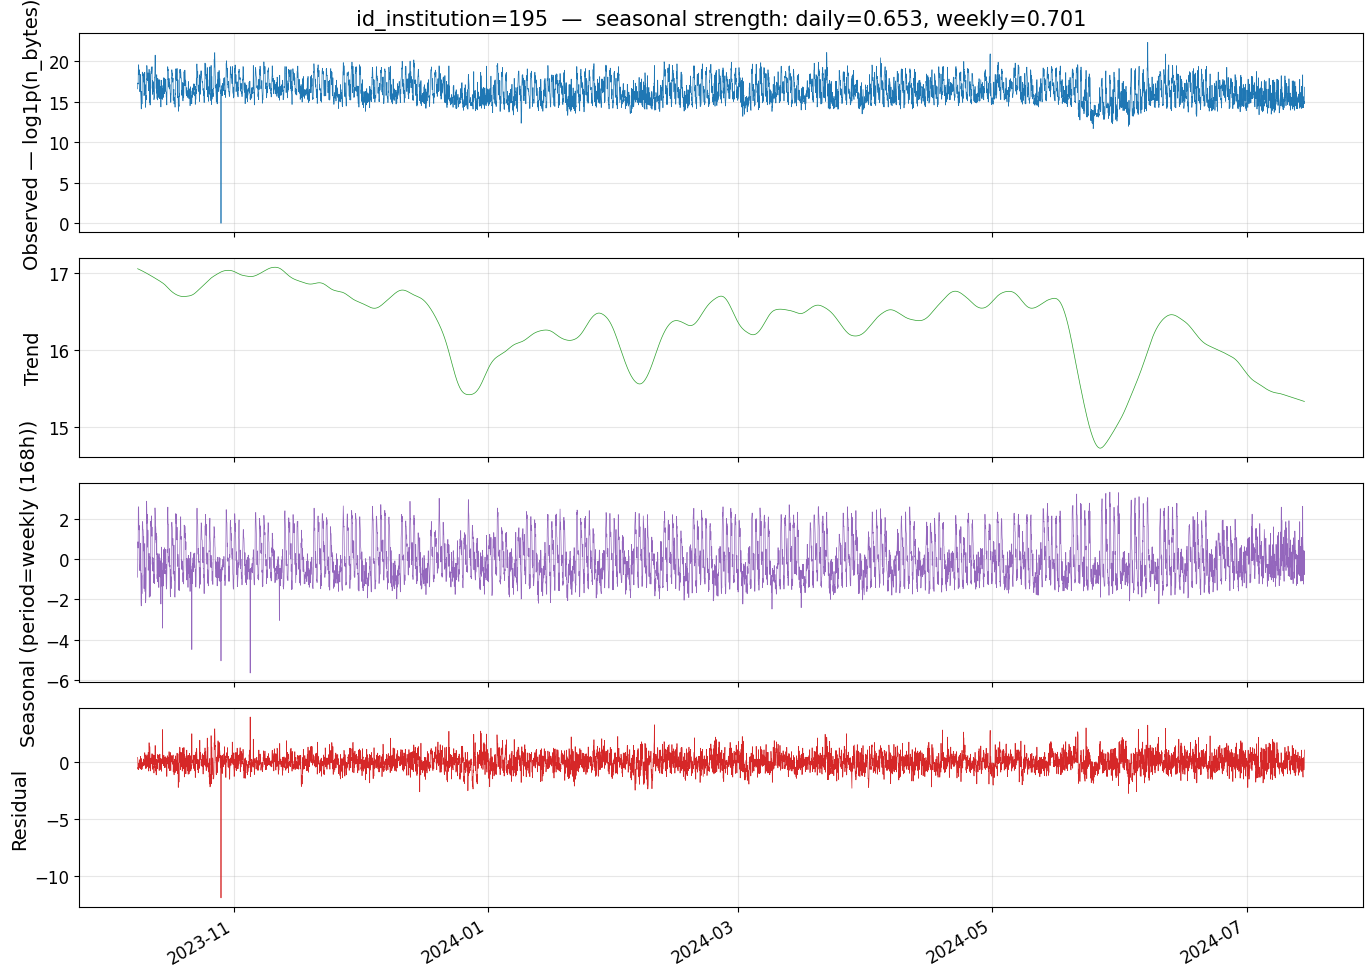

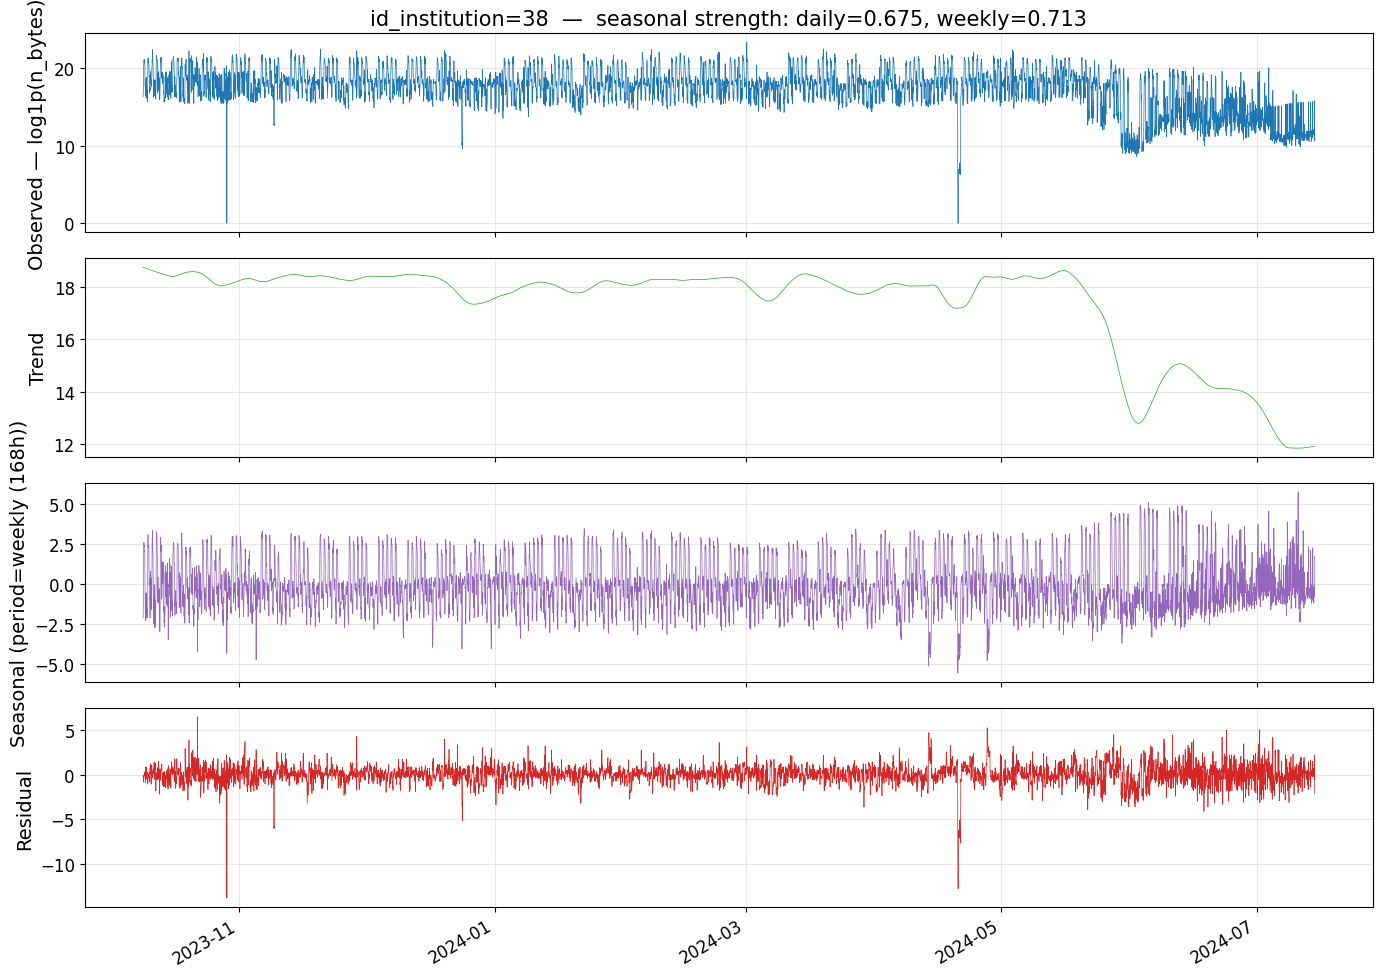

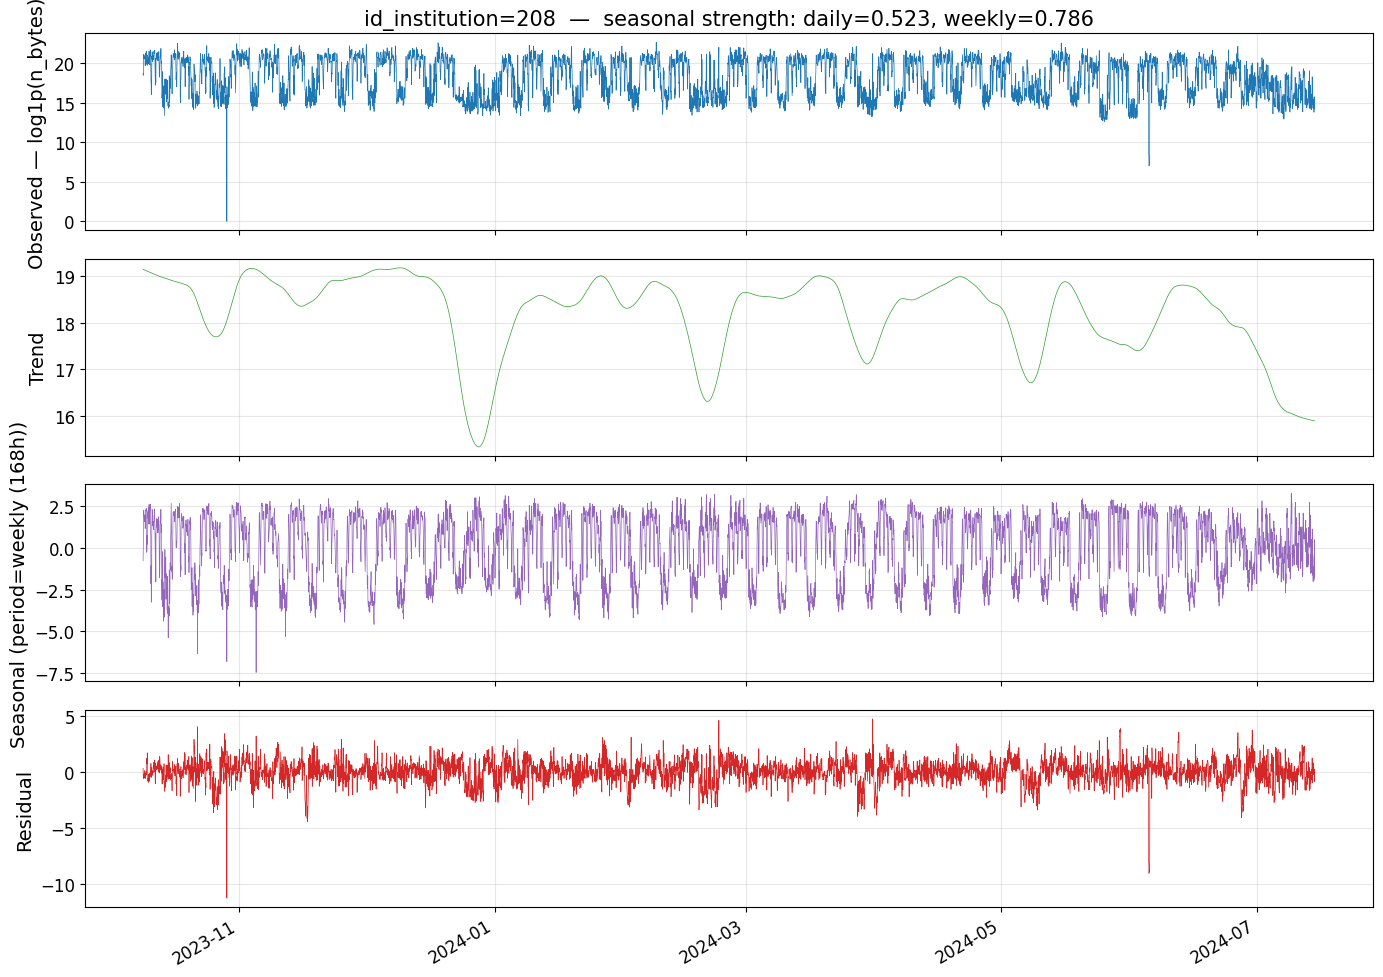

100%|████████████████████████████| 3/3 [00:07<00:00,  2.51s/it]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [136 405 451], Length=3
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch size: 128

subnets (AGG_1_HOUR): 3 series loaded

SUBNETS — verifying 3 series


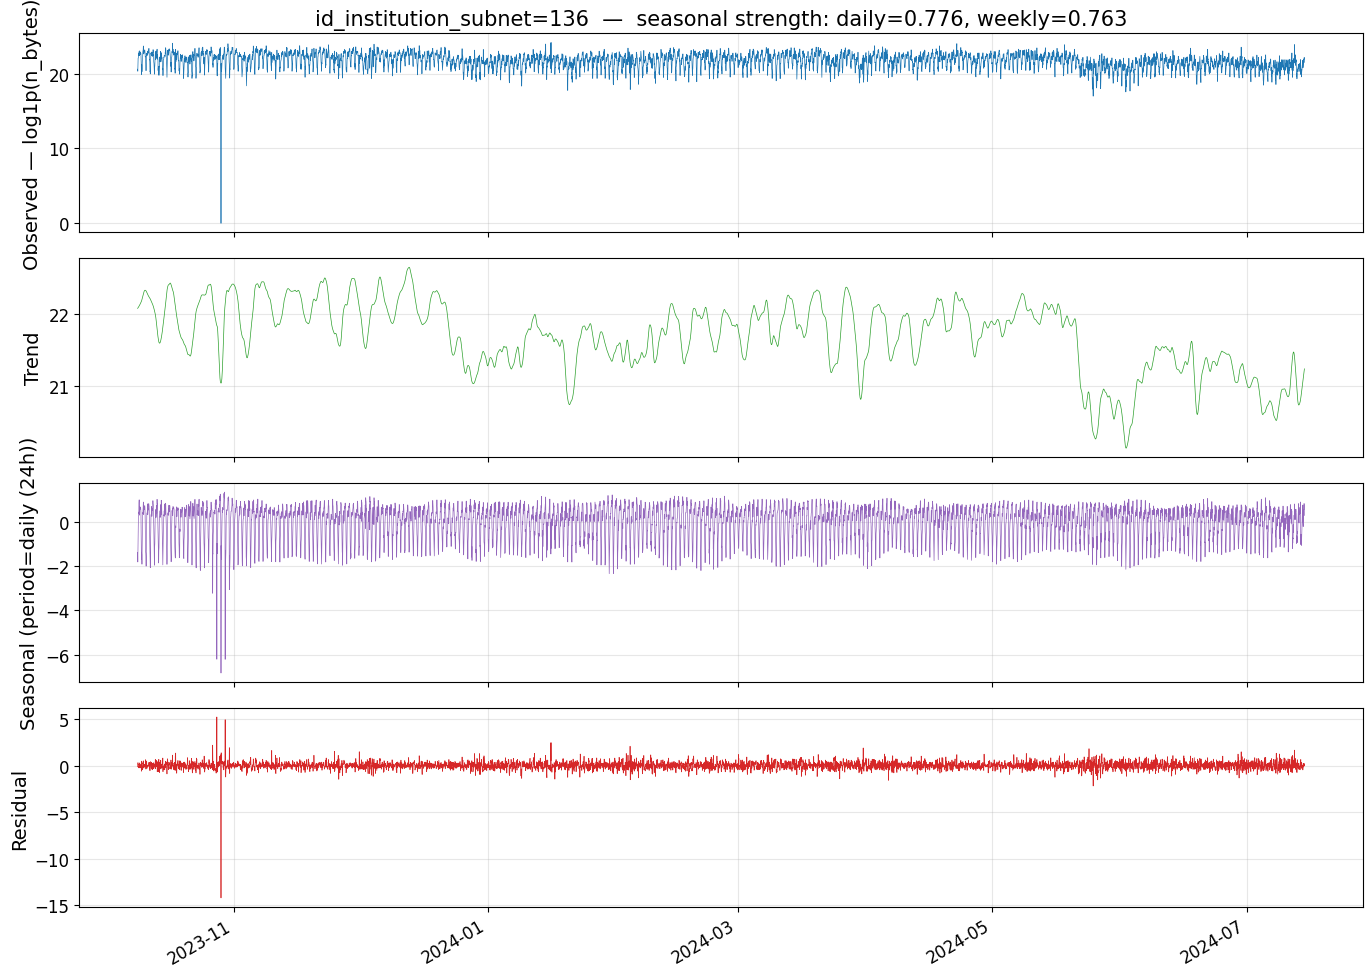

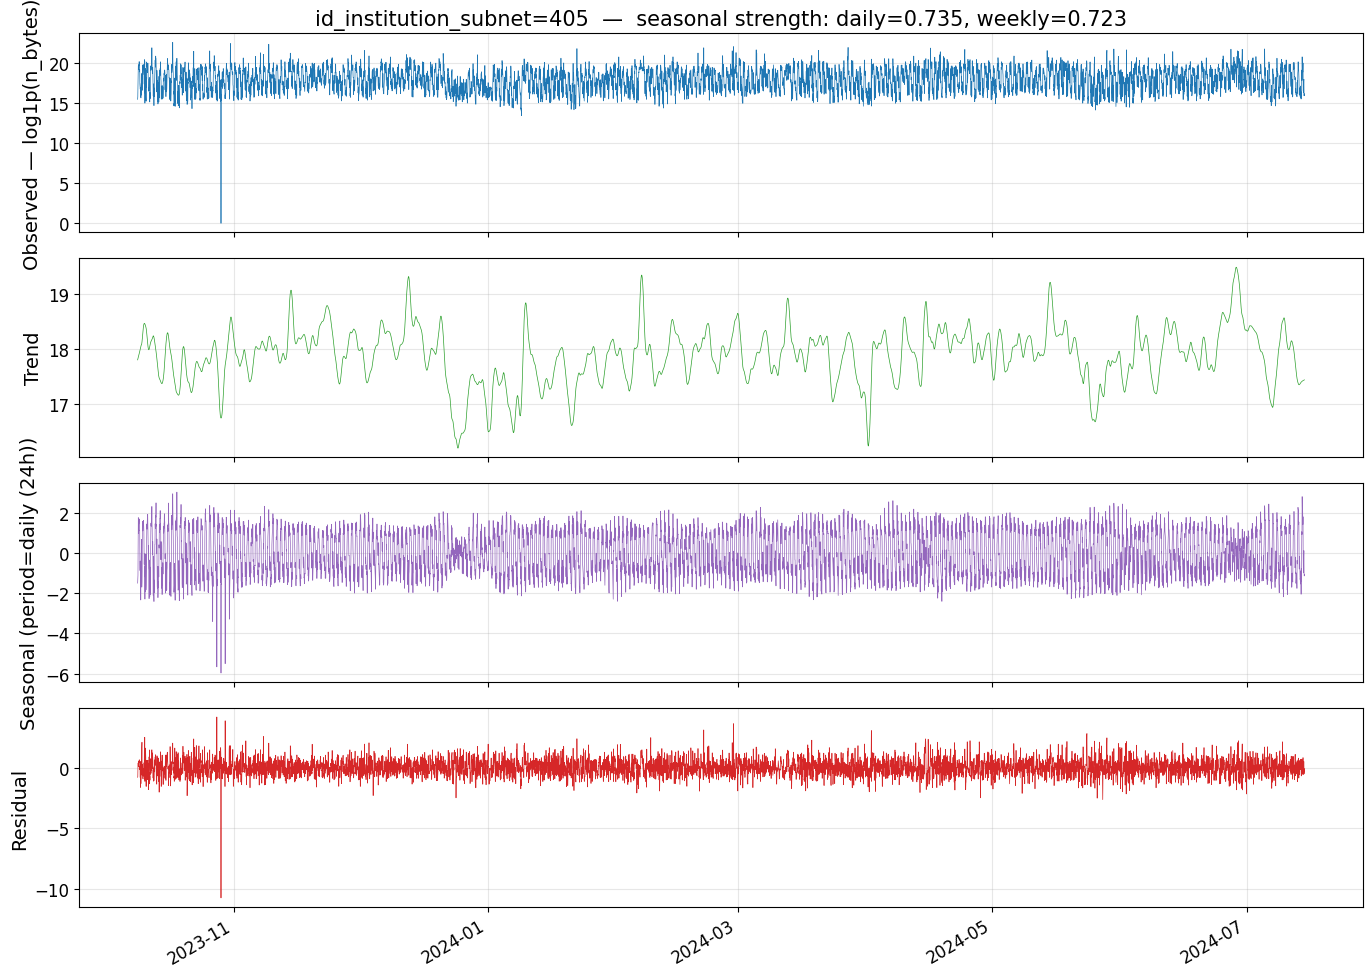

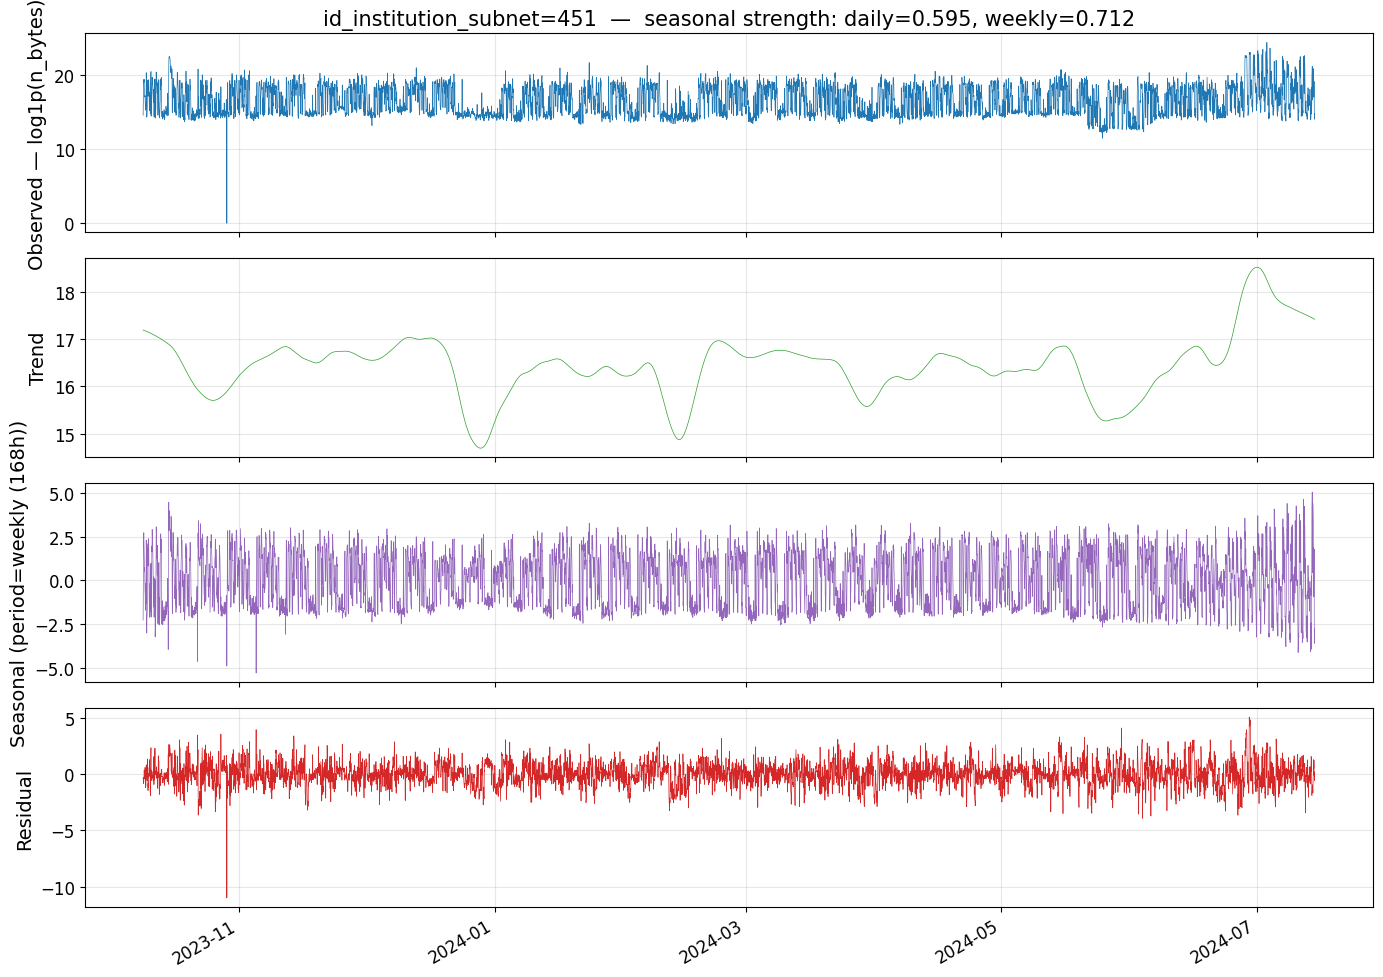

100%|████████████████████████████| 3/3 [00:07<00:00,  2.54s/it]


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [114939 626876 250872], Length=3
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch si

ips_full (AGG_1_HOUR): 3 series loaded

IPS — verifying 3 series


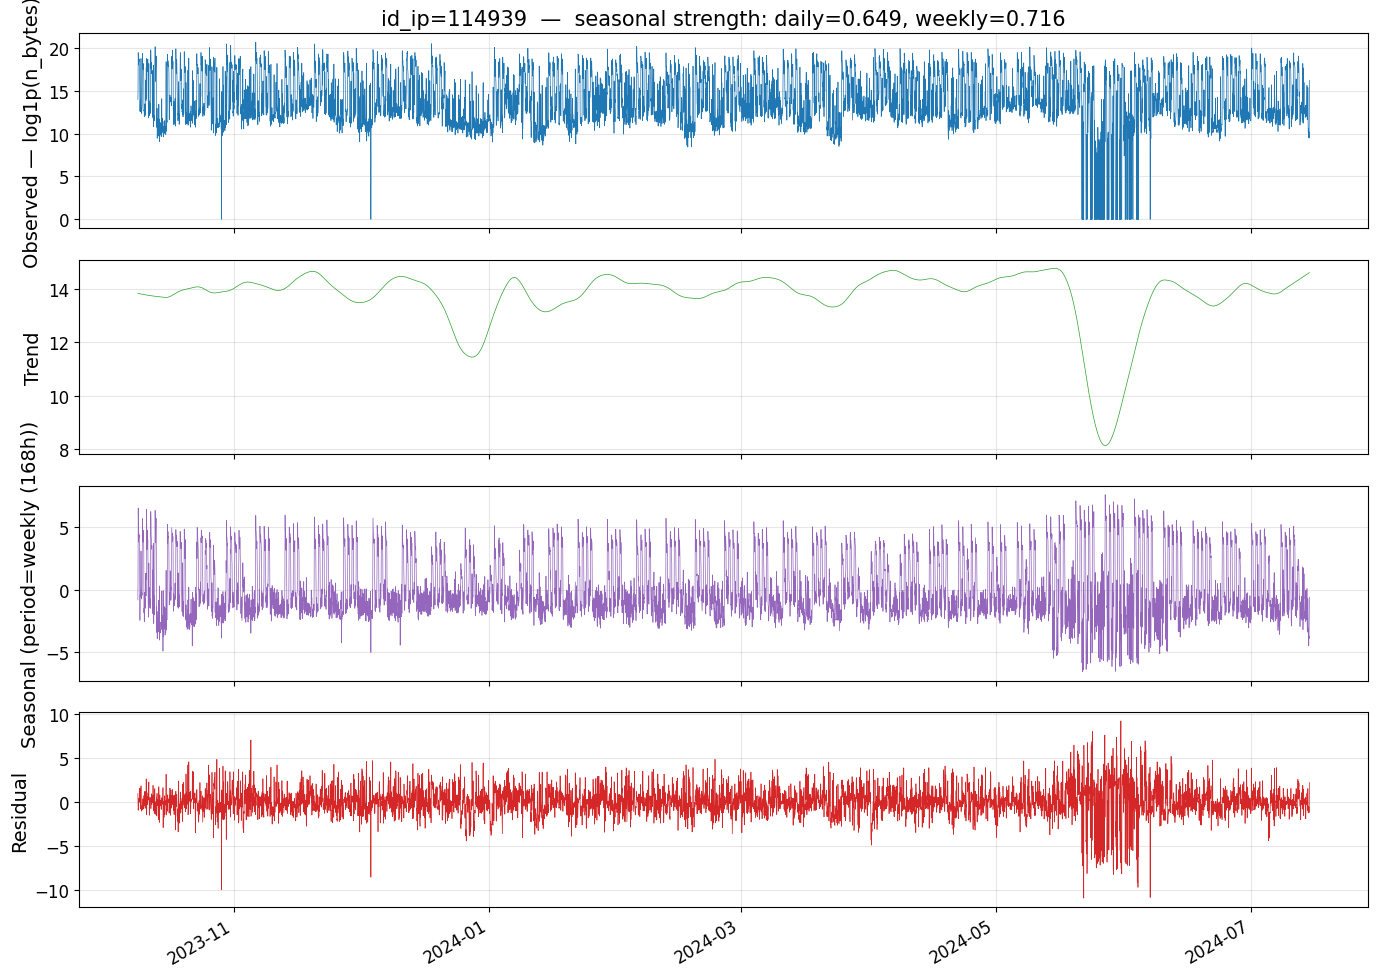

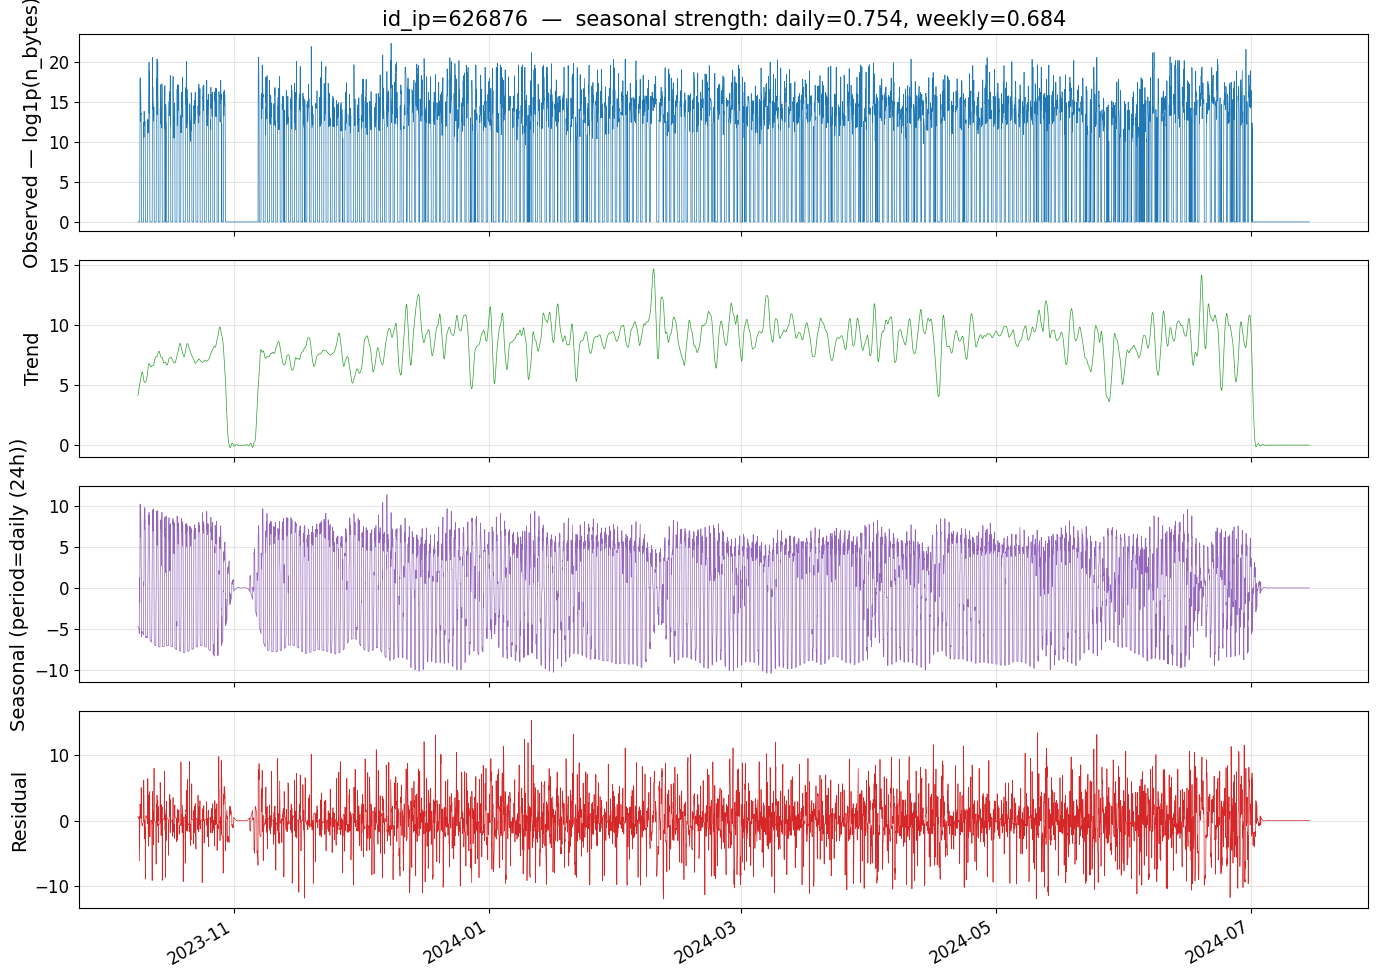

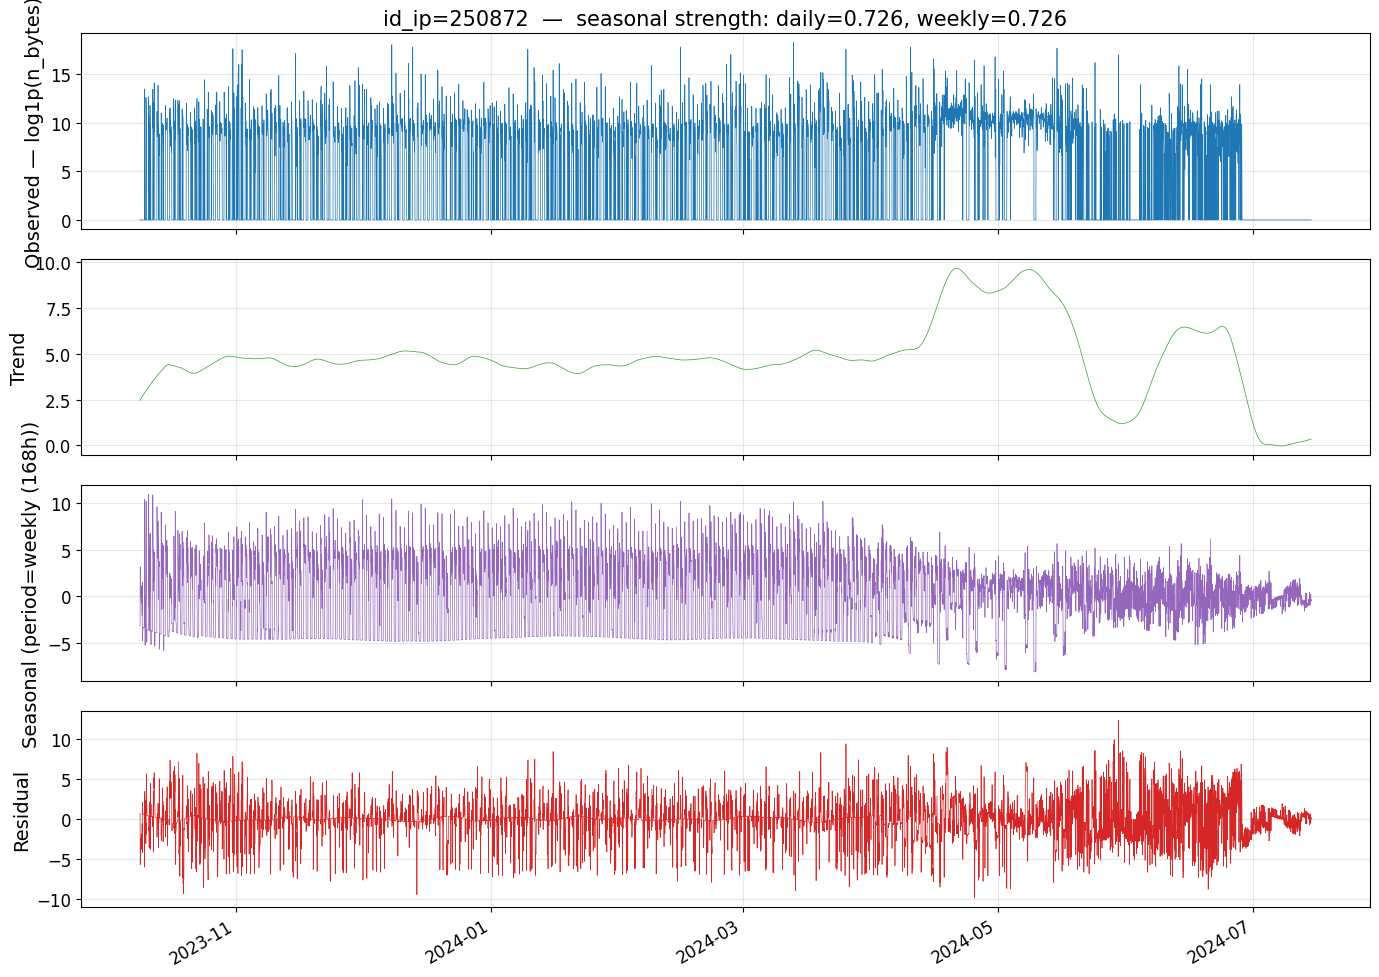

In [9]:
N_VERIFY = 3
rng = np.random.default_rng(RANDOM_SEED)

for source in sources:
    _, id_col = SOURCE_MAP[source]
    verify_ids = rng.choice(selected[source], size=min(N_VERIFY, len(selected[source])), replace=False).tolist()
    load_source = "ips_full" if source == "ips" else source
    data = load_dataset(load_source, aggregation=AGG_PARAMS["enum"], time_range=AGG_PARAMS["time_range"], ts_ids=verify_ids)
    df = data["df"]
    print(f"\n{'='*60}")
    print(f"{source.upper()} — verifying {len(verify_ids)} series")
    print(f"{'='*60}")
    for ts_id in verify_ids:
        plot_stl_verification(df, id_col, ts_id, AGG_PARAMS)

## 6 — Save selection

In [10]:
save_selection(selected, BENCHMARK, AGGREGATION)

Saved selected_ids/hourly/SEASON.csv (75 series)


'selected_ids/hourly/SEASON.csv'